# Classificação de Risco Pedagógico com Machine Learning

Este notebook utiliza um **dataset educacional sintético com padrões realistas**, criado para fins acadêmicos, com o objetivo de prever a situação final do aluno:

- `Aprovado`
- `Reprovado`

A metodologia mantém o **conjunto de teste separado**, usando-o apenas na avaliação final.  
O objetivo é comparar modelos de Machine Learning e alcançar um desempenho mais consistente, com F1-score da classe `Reprovado` em torno de **0.85 a 0.90**.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

In [2]:
# Opção 1: Colab com upload manual
# Execute esta célula no Colab se os arquivos ainda não estiverem no ambiente.

# try:
#     from google.colab import files
#     uploaded = files.upload()
#     print("Arquivos enviados:", list(uploaded.keys()))
# except Exception:
#     print("Ambiente local detectado. Pule esta célula se estiver usando VS Code.")

In [3]:
from pathlib import Path

# Ajuste automático para Colab ou VS Code
caminhos_possiveis = [
    Path("dataset_treino_validacao_padrao_realista.csv"),
    Path("/content/dataset_treino_validacao_padrao_realista.csv"),
    Path("../data/processed/dataset_treino_validacao_padrao_realista.csv"),
    Path("data/processed/dataset_treino_validacao_padrao_realista.csv")
]

caminhos_teste_possiveis = [
    Path("dataset_teste_final_padrao_realista.csv"),
    Path("/content/dataset_teste_final_padrao_realista.csv"),
    Path("../data/processed/dataset_teste_final_padrao_realista.csv"),
    Path("data/processed/dataset_teste_final_padrao_realista.csv")
]

path_tv = next((p for p in caminhos_possiveis if p.exists()), None)
path_teste = next((p for p in caminhos_teste_possiveis if p.exists()), None)

if path_tv is None:
    raise FileNotFoundError("Arquivo dataset_treino_validacao_padrao_realista.csv não encontrado.")

if path_teste is None:
    raise FileNotFoundError("Arquivo dataset_teste_final_padrao_realista.csv não encontrado.")

df_tv = pd.read_csv(path_tv)
df_teste_final = pd.read_csv(path_teste)

print("Treino + validação:", df_tv.shape)
print("Teste final:", df_teste_final.shape)

display(df_tv.head())

Treino + validação: (10200, 26)
Teste final: (1800, 26)


,id_aluno,idade,sexo,renda_familiar,escolaridade_mae,turno,trabalha,acesso_internet,computador_casa,transporte_escolar,distancia_escola_km,frequencia_percent,faltas,atrasos,horas_estudo_dia,participacao_aulas,atividades_entregues_percent,apoio_familiar,reprovacoes_anteriores,nota_matematica,nota_portugues,nota_ciencias,nota_humanas,media,situacao_final,split_sugerido
0,1,16,F,media,medio,Manha,Nao,Sim,Nao,Sim,4.1,63.0,19,9,0.6,71.3,60.4,61.0,0,5.7,4.9,4.6,7.3,5.62,Reprovado,treino
1,2,16,F,alta,medio,Manha,Nao,Sim,Nao,Nao,2.7,81.4,11,15,1.2,86.9,88.7,74.4,0,6.5,7.5,5.4,9.1,7.12,Aprovado,treino
2,3,15,F,media,medio,Noite,Nao,Sim,Nao,Nao,2.2,73.0,20,23,0.4,83.9,72.0,51.0,0,6.6,4.5,5.8,5.6,5.62,Reprovado,treino
3,4,17,M,media,fundamental,Tarde,Nao,Nao,Sim,Sim,8.7,57.5,11,4,2.6,29.9,56.1,22.4,0,2.2,5.0,5.5,4.6,4.32,Reprovado,treino
4,5,13,F,media,medio,Noite,Nao,Sim,Sim,Nao,2.3,72.7,7,5,2.9,83.8,92.8,83.6,1,9.2,10.0,5.9,8.2,8.32,Aprovado,treino


## 3. Conferência da separação do teste

Aqui verificamos se os IDs do conjunto de teste não aparecem na base de treino/validação.  
O resultado esperado é `0`.

In [4]:
ids_tv = set(df_tv["id_aluno"])
ids_teste = set(df_teste_final["id_aluno"])

intersecao = ids_tv.intersection(ids_teste)

print("Quantidade de IDs repetidos entre treino/validação e teste:")
print(len(intersecao))

Quantidade de IDs repetidos entre treino/validação e teste:
0


## 4. Análise inicial da variável alvo

Distribuição em treino + validação:


,count
situacao_final,
Aprovado,6316
Reprovado,3884


,proportion
situacao_final,
Aprovado,61.921569
Reprovado,38.078431


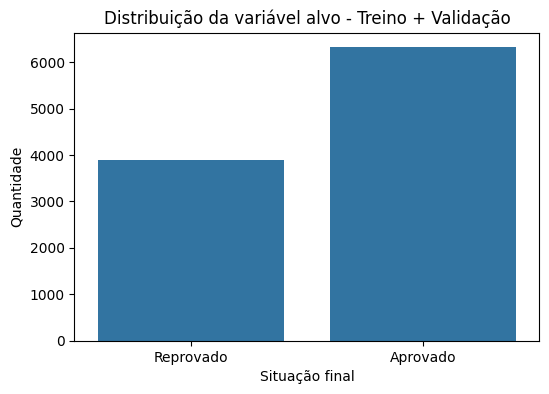

In [5]:
print("Distribuição em treino + validação:")
display(df_tv["situacao_final"].value_counts())
display(df_tv["situacao_final"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_tv, x="situacao_final")
plt.title("Distribuição da variável alvo - Treino + Validação")
plt.xlabel("Situação final")
plt.ylabel("Quantidade")
plt.show()

In [6]:
print("Distribuição no teste final:")
display(df_teste_final["situacao_final"].value_counts())
display(df_teste_final["situacao_final"].value_counts(normalize=True) * 100)

Distribuição no teste final:


,count
situacao_final,
Aprovado,1115
Reprovado,685


,proportion
situacao_final,
Aprovado,61.944444
Reprovado,38.055556


## 5. Criação de variáveis derivadas

As variáveis derivadas ajudam os modelos a capturar padrões mais claros, como:

- média das notas;
- menor nota;
- quantidade de notas baixas;
- indicadores de baixa frequência, muitas faltas e atrasos;
- índice geral de risco acadêmico.

Essas variáveis **não usam a variável alvo** e, portanto, não causam vazamento de informação.

In [7]:
def criar_variaveis_derivadas(df):
    df = df.copy()

    colunas_notas = [
        "nota_matematica",
        "nota_portugues",
        "nota_ciencias",
        "nota_humanas"
    ]

    df["media_notas"] = df[colunas_notas].mean(axis=1)
    df["menor_nota"] = df[colunas_notas].min(axis=1)
    df["maior_nota"] = df[colunas_notas].max(axis=1)

    df["qtd_notas_baixas"] = (
        df[colunas_notas] < 6
    ).sum(axis=1)

    df["frequencia_baixa"] = (
        df["frequencia_percent"] < 75
    ).astype(int)

    df["muitas_faltas"] = (
        df["faltas"] >= 15
    ).astype(int)

    df["muitos_atrasos"] = (
        df["atrasos"] >= 10
    ).astype(int)

    df["baixa_entrega_atividades"] = (
        df["atividades_entregues_percent"] < 70
    ).astype(int)

    df["baixa_participacao"] = (
        df["participacao_aulas"] < 70
    ).astype(int)

    df["risco_academico"] = (
        df["frequencia_baixa"]
        + df["muitas_faltas"]
        + df["muitos_atrasos"]
        + df["baixa_entrega_atividades"]
        + df["baixa_participacao"]
        + df["qtd_notas_baixas"]
        + df["reprovacoes_anteriores"]
    )

    df["diferenca_freq_atividades"] = (
        df["frequencia_percent"] - df["atividades_entregues_percent"]
    )

    return df


df_tv = criar_variaveis_derivadas(df_tv)
df_teste_final = criar_variaveis_derivadas(df_teste_final)

display(df_tv.head())

,id_aluno,idade,sexo,renda_familiar,escolaridade_mae,turno,trabalha,acesso_internet,computador_casa,transporte_escolar,distancia_escola_km,frequencia_percent,faltas,atrasos,horas_estudo_dia,participacao_aulas,atividades_entregues_percent,apoio_familiar,reprovacoes_anteriores,nota_matematica,nota_portugues,nota_ciencias,nota_humanas,media,situacao_final,split_sugerido,media_notas,menor_nota,maior_nota,qtd_notas_baixas,frequencia_baixa,muitas_faltas,muitos_atrasos,baixa_entrega_atividades,baixa_participacao,risco_academico,diferenca_freq_atividades
0,1,16,F,media,medio,Manha,Nao,Sim,Nao,Sim,4.1,63.0,19,9,0.6,71.3,60.4,61.0,0,5.7,4.9,4.6,7.3,5.62,Reprovado,treino,5.625,4.6,7.3,3,1,1,0,1,0,6,2.6
1,2,16,F,alta,medio,Manha,Nao,Sim,Nao,Nao,2.7,81.4,11,15,1.2,86.9,88.7,74.4,0,6.5,7.5,5.4,9.1,7.12,Aprovado,treino,7.125,5.4,9.1,1,0,0,1,0,0,2,-7.3
2,3,15,F,media,medio,Noite,Nao,Sim,Nao,Nao,2.2,73.0,20,23,0.4,83.9,72.0,51.0,0,6.6,4.5,5.8,5.6,5.62,Reprovado,treino,5.625,4.5,6.6,3,1,1,1,0,0,6,1.0
3,4,17,M,media,fundamental,Tarde,Nao,Nao,Sim,Sim,8.7,57.5,11,4,2.6,29.9,56.1,22.4,0,2.2,5.0,5.5,4.6,4.32,Reprovado,treino,4.325,2.2,5.5,4,1,0,0,1,1,7,1.4
4,5,13,F,media,medio,Noite,Nao,Sim,Sim,Nao,2.3,72.7,7,5,2.9,83.8,92.8,83.6,1,9.2,10.0,5.9,8.2,8.32,Aprovado,treino,8.325,5.9,10.0,1,1,0,0,0,0,3,-20.1


## 6. Definição das variáveis de entrada e alvo

In [8]:
variaveis_entrada = [
    # Variáveis originais
    "frequencia_percent",
    "faltas",
    "atrasos",
    "horas_estudo_dia",
    "participacao_aulas",
    "atividades_entregues_percent",
    "apoio_familiar",
    "reprovacoes_anteriores",
    "nota_matematica",
    "nota_portugues",
    "nota_ciencias",
    "nota_humanas",
    "media",

    # Variáveis derivadas
    "media_notas",
    "menor_nota",
    "maior_nota",
    "qtd_notas_baixas",
    "frequencia_baixa",
    "muitas_faltas",
    "muitos_atrasos",
    "baixa_entrega_atividades",
    "baixa_participacao",
    "risco_academico",
    "diferenca_freq_atividades"
]

alvo = "situacao_final"

X = df_tv[variaveis_entrada]
y = df_tv[alvo]

print("X:", X.shape)
print("y:", y.shape)

X: (10200, 24)
y: (10200,)


## 7. Separação de treino e validação

O conjunto de teste já está separado em outro arquivo.  
Aqui, usamos apenas `df_tv` para criar treino e validação.

A variável `percentual_treino` pode ser alterada durante uma demonstração ao vivo.

In [9]:
percentual_treino = 0.70

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=percentual_treino,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)

print("\nDistribuição treino:")
display(y_train.value_counts())

print("\nDistribuição validação:")
display(y_val.value_counts())

Treino: (7140, 24)
Validação: (3060, 24)

Distribuição treino:


,count
situacao_final,
Aprovado,4421
Reprovado,2719



Distribuição validação:


,count
situacao_final,
Aprovado,1895
Reprovado,1165


## 8. Função de avaliação

A métrica principal será o **F1-score da classe Reprovado**, pois o objetivo é identificar corretamente alunos com risco de reprovação, equilibrando precisão e recall.

In [10]:
def avaliar_modelo(nome_modelo, modelo, X_val, y_val):
    y_pred = modelo.predict(X_val)

    resultado = {
        "modelo": nome_modelo,
        "acuracia": accuracy_score(y_val, y_pred),
        "precisao_reprovado": precision_score(
            y_val, y_pred, pos_label="Reprovado", zero_division=0
        ),
        "recall_reprovado": recall_score(
            y_val, y_pred, pos_label="Reprovado", zero_division=0
        ),
        "f1_reprovado": f1_score(
            y_val, y_pred, pos_label="Reprovado", zero_division=0
        )
    }

    print(f"Relatório de classificação — {nome_modelo}")
    print(classification_report(y_val, y_pred, zero_division=0))

    return resultado

## 9. Modelos avaliados

Serão avaliados modelos baseline e modelos mais avançados:

- Regressão Logística
- Árvore de Decisão
- Random Forest
- Gradient Boosting
- Extra Trees
- Voting Classifier
- SVM Linear
- SVM RBF
- Rede Neural MLP

In [11]:
modelos = {
    "Regressão Logística": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Árvore de Decisão": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("modelo", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("modelo", RandomForestClassifier(
            n_estimators=250,
            max_depth=10,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("modelo", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "Extra Trees": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("modelo", ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVM Linear": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="linear",
            C=1,
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "SVM RBF C=1": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "Rede Neural MLP 32-16": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=700,
            random_state=42
        ))
    ])
}

In [12]:
# Voting Classifier separado porque combina modelos internos
modelos["Voting Classifier"] = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("modelo", VotingClassifier(
        estimators=[
            ("logistica", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )),
            ("arvore", DecisionTreeClassifier(
                max_depth=6,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42
            )),
            ("random_forest", RandomForestClassifier(
                n_estimators=250,
                max_depth=10,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42
            ))
        ],
        voting="soft"
    ))
])

## 10. Treinamento e avaliação na validação

O teste final ainda não será usado.

In [13]:
resultados_validacao = []
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    resultado = avaliar_modelo(
        nome_modelo=nome,
        modelo=modelo,
        X_val=X_val,
        y_val=y_val
    )

    resultados_validacao.append(resultado)
    modelos_treinados[nome] = modelo

df_resultados_validacao = pd.DataFrame(resultados_validacao)

df_resultados_validacao = df_resultados_validacao.sort_values(
    by="f1_reprovado",
    ascending=False
)

display(df_resultados_validacao)

Relatório de classificação — Regressão Logística
              precision    recall  f1-score   support

    Aprovado       0.90      0.94      0.92      1895
   Reprovado       0.90      0.82      0.86      1165

    accuracy                           0.90      3060
   macro avg       0.90      0.88      0.89      3060
weighted avg       0.90      0.90      0.90      3060

Relatório de classificação — Árvore de Decisão
              precision    recall  f1-score   support

    Aprovado       0.89      0.94      0.91      1895
   Reprovado       0.89      0.81      0.85      1165

    accuracy                           0.89      3060
   macro avg       0.89      0.87      0.88      3060
weighted avg       0.89      0.89      0.89      3060

Relatório de classificação — Random Forest
              precision    recall  f1-score   support

    Aprovado       0.90      0.95      0.92      1895
   Reprovado       0.90      0.82      0.86      1165

    accuracy                           0.90

,modelo,acuracia,precisao_reprovado,recall_reprovado,f1_reprovado
6,SVM RBF C=1,0.900980,0.907372,0.824034,0.863698
5,SVM Linear,0.900654,0.905749,0.824893,0.863432
4,Extra Trees,0.899673,0.904717,0.823176,0.862022
2,Random Forest,0.898693,0.902922,0.822318,0.860737
3,Gradient Boosting,0.898693,0.905983,0.818884,0.860234
8,Voting Classifier,0.897712,0.901130,0.821459,0.859452
0,Regressão Logística,0.897059,0.897196,0.824034,0.859060
1,Árvore de Decisão,0.888889,0.891738,0.806009,0.846709
7,Rede Neural MLP 32-16,0.849346,0.833333,0.755365,0.792436


## 11. Teste adicional com SMOTE

O SMOTE é aplicado **somente no treino**, nunca na validação ou no teste.

In [14]:
modelos_smote = {
    "Regressão Logística + SMOTE": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest + SMOTE": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ),

    "Extra Trees + SMOTE": ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    )
}

for nome, modelo in modelos_smote.items():

    pipeline_smote = ImbPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("modelo", modelo)
    ])

    pipeline_smote.fit(X_train, y_train)

    resultado = avaliar_modelo(
        nome_modelo=nome,
        modelo=pipeline_smote,
        X_val=X_val,
        y_val=y_val
    )

    resultados_validacao.append(resultado)
    modelos_treinados[nome] = pipeline_smote

df_resultados_validacao = pd.DataFrame(resultados_validacao)

df_resultados_validacao = df_resultados_validacao.sort_values(
    by="f1_reprovado",
    ascending=False
)

display(df_resultados_validacao)

Relatório de classificação — Regressão Logística + SMOTE
              precision    recall  f1-score   support

    Aprovado       0.90      0.94      0.92      1895
   Reprovado       0.90      0.83      0.86      1165

    accuracy                           0.90      3060
   macro avg       0.90      0.88      0.89      3060
weighted avg       0.90      0.90      0.90      3060

Relatório de classificação — Random Forest + SMOTE
              precision    recall  f1-score   support

    Aprovado       0.90      0.95      0.92      1895
   Reprovado       0.90      0.82      0.86      1165

    accuracy                           0.90      3060
   macro avg       0.90      0.88      0.89      3060
weighted avg       0.90      0.90      0.90      3060

Relatório de classificação — Extra Trees + SMOTE
              precision    recall  f1-score   support

    Aprovado       0.90      0.95      0.92      1895
   Reprovado       0.91      0.82      0.86      1165

    accuracy             

,modelo,acuracia,precisao_reprovado,recall_reprovado,f1_reprovado
6,SVM RBF C=1,0.900980,0.907372,0.824034,0.863698
5,SVM Linear,0.900654,0.905749,0.824893,0.863432
11,Extra Trees + SMOTE,0.900000,0.905571,0.823176,0.862410
4,Extra Trees,0.899673,0.904717,0.823176,0.862022
10,Random Forest + SMOTE,0.898693,0.902922,0.822318,0.860737
2,Random Forest,0.898693,0.902922,0.822318,0.860737
9,Regressão Logística + SMOTE,0.898039,0.897484,0.826609,0.860590
3,Gradient Boosting,0.898693,0.905983,0.818884,0.860234
8,Voting Classifier,0.897712,0.901130,0.821459,0.859452
0,Regressão Logística,0.897059,0.897196,0.824034,0.859060


## 12. Escolha do modelo vencedor na validação

O modelo vencedor é escolhido pelo maior F1-score da classe `Reprovado`.

In [15]:
melhor_nome = df_resultados_validacao.iloc[0]["modelo"]
melhor_modelo = modelos_treinados[melhor_nome]

print("Modelo vencedor na validação:")
print(melhor_nome)

display(df_resultados_validacao.head(10))

Modelo vencedor na validação:
SVM RBF C=1


,modelo,acuracia,precisao_reprovado,recall_reprovado,f1_reprovado
6,SVM RBF C=1,0.900980,0.907372,0.824034,0.863698
5,SVM Linear,0.900654,0.905749,0.824893,0.863432
11,Extra Trees + SMOTE,0.900000,0.905571,0.823176,0.862410
4,Extra Trees,0.899673,0.904717,0.823176,0.862022
10,Random Forest + SMOTE,0.898693,0.902922,0.822318,0.860737
2,Random Forest,0.898693,0.902922,0.822318,0.860737
9,Regressão Logística + SMOTE,0.898039,0.897484,0.826609,0.860590
3,Gradient Boosting,0.898693,0.905983,0.818884,0.860234
8,Voting Classifier,0.897712,0.901130,0.821459,0.859452
0,Regressão Logística,0.897059,0.897196,0.824034,0.859060


## 13. Avaliação final no conjunto de teste

Agora sim o arquivo de teste final será usado.  
Ele foi mantido separado até este momento.

In [16]:
X_test = df_teste_final[variaveis_entrada]
y_test = df_teste_final[alvo]

y_pred_test = melhor_modelo.predict(X_test)

resultado_teste = {
    "modelo": melhor_nome,
    "acuracia_teste": accuracy_score(y_test, y_pred_test),
    "precisao_reprovado": precision_score(y_test, y_pred_test, pos_label="Reprovado", zero_division=0),
    "recall_reprovado": recall_score(y_test, y_pred_test, pos_label="Reprovado", zero_division=0),
    "f1_reprovado": f1_score(y_test, y_pred_test, pos_label="Reprovado", zero_division=0)
}

df_resultado_teste = pd.DataFrame([resultado_teste])

display(df_resultado_teste)

print("\nRelatório de classificação no teste final:")
print(classification_report(y_test, y_pred_test, zero_division=0))

,modelo,acuracia_teste,precisao_reprovado,recall_reprovado,f1_reprovado
0,SVM RBF C=1,0.896111,0.892744,0.826277,0.858226



Relatório de classificação no teste final:
              precision    recall  f1-score   support

    Aprovado       0.90      0.94      0.92      1115
   Reprovado       0.89      0.83      0.86       685

    accuracy                           0.90      1800
   macro avg       0.90      0.88      0.89      1800
weighted avg       0.90      0.90      0.90      1800



## 14. Matriz de confusão

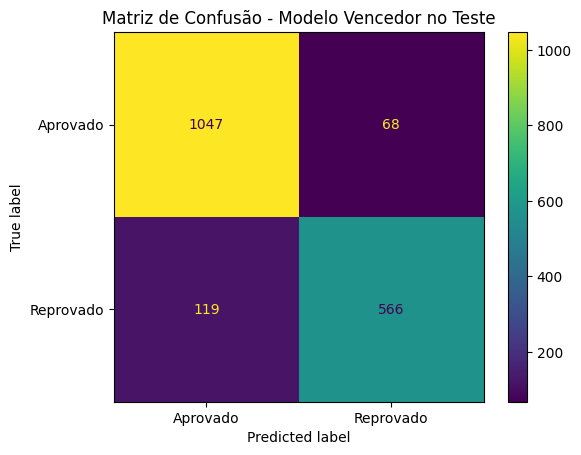

In [17]:
cm = confusion_matrix(y_test, y_pred_test, labels=["Aprovado", "Reprovado"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Aprovado", "Reprovado"]
)

disp.plot()
plt.title("Matriz de Confusão - Modelo Vencedor no Teste")
plt.show()

In [18]:
df_exemplos = df_teste_final.copy()
df_exemplos["valor_previsto"] = y_pred_test

if hasattr(melhor_modelo, "predict_proba"):
    probas = melhor_modelo.predict_proba(X_test)
    classes = melhor_modelo.classes_

    df_probas = pd.DataFrame(
        probas,
        columns=[f"prob_{classe}" for classe in classes],
        index=df_exemplos.index
    )

    df_exemplos = pd.concat([df_exemplos, df_probas], axis=1)

exemplo_aprovado_correto = df_exemplos[
    (df_exemplos["situacao_final"] == "Aprovado") &
    (df_exemplos["valor_previsto"] == "Aprovado")
].head(1)

exemplo_reprovado_correto = df_exemplos[
    (df_exemplos["situacao_final"] == "Reprovado") &
    (df_exemplos["valor_previsto"] == "Reprovado")
].head(1)

colunas_exemplo = [
    "id_aluno",
    "frequencia_percent",
    "faltas",
    "atrasos",
    "horas_estudo_dia",
    "participacao_aulas",
    "atividades_entregues_percent",
    "apoio_familiar",
    "reprovacoes_anteriores",
    "media",
    "situacao_final",
    "valor_previsto"
]

colunas_prob = [c for c in df_exemplos.columns if c.startswith("prob_")]
colunas_exemplo = colunas_exemplo + colunas_prob

print("Exemplo aprovado corretamente:")
display(exemplo_aprovado_correto[colunas_exemplo])

print("Exemplo reprovado corretamente:")
display(exemplo_reprovado_correto[colunas_exemplo])

Exemplo aprovado corretamente:


,id_aluno,frequencia_percent,faltas,atrasos,horas_estudo_dia,participacao_aulas,atividades_entregues_percent,apoio_familiar,reprovacoes_anteriores,media,situacao_final,valor_previsto,prob_Aprovado,prob_Reprovado
0,10,77.1,17,7,2.8,77.3,89.1,58.8,1,8.0,Aprovado,Aprovado,0.885697,0.114303


Exemplo reprovado corretamente:


,id_aluno,frequencia_percent,faltas,atrasos,horas_estudo_dia,participacao_aulas,atividades_entregues_percent,apoio_familiar,reprovacoes_anteriores,media,situacao_final,valor_previsto,prob_Aprovado,prob_Reprovado
4,73,57.4,21,12,0.7,65.0,90.5,42.7,1,5.25,Reprovado,Reprovado,0.073194,0.926806


## 16. Exportação dos resultados

In [19]:
df_resultados_validacao.to_csv("resultados_validacao.csv", index=False, encoding="utf-8-sig")
df_resultado_teste.to_csv("resultado_teste_final.csv", index=False, encoding="utf-8-sig")

print("Arquivos exportados:")
print("- resultados_validacao.csv")
print("- resultado_teste_final.csv")

Arquivos exportados:
- resultados_validacao.csv
- resultado_teste_final.csv
